# Лабораторная работа 2

Лекция «Обзор библиотек Python для сбора и анализа веб-данных».

| Задание | Слайд | Инструменты |
|---|---|---|
| Паук на Scrapy (`task1`) | 12 | scrapy |
| Граф ресурсов по металлургии (`task2`) | 17 | requests, bs4, rutermextract, graphviz |

Тетрадь запускает оба задания и сохраняет результаты. Установка описана в `README.md`.

In [2]:
import json
import subprocess
import sys
from pathlib import Path

LAB = Path.cwd()

def run(*command, cwd, tail=None):
    print("$", " ".join(str(part) for part in command))
    result = subprocess.run(
        [sys.executable, *[str(part) for part in command]],
        cwd=LAB / cwd, capture_output=True, text=True, encoding="utf-8", errors="replace",
    )
    lines = (result.stdout + result.stderr).splitlines()
    print("\n".join(lines[-tail:] if tail else lines))
    return result.returncode

MIN_COMMON = 4    # сколько общих терминов даёт ребро
TOP_TERMS = 30    # сколько терминов брать с ресурса

print("Python", sys.version.split()[0])
for package in ("scrapy", "requests", "bs4", "lxml", "graphviz", "rutermextract", "pymorphy3"):
    module = __import__(package)
    print(f"{package:14} {getattr(module, '__version__', 'ok')}")

Python 3.12.7
scrapy         2.19.0
requests       2.32.5
bs4            4.14.3
lxml           5.3.0
graphviz       0.21
rutermextract  ok
pymorphy3      2.0.6


---
# Задание 1. Паук на Scrapy

Цель обхода — `quotes.toscrape.com`, учебный полигон Scrapy. Паук берёт с каждой страницы
текст цитаты, автора и теги, затем переходит по ссылке «Next», пока она есть.

In [3]:
print((LAB / "task1/quotes/spiders/quotes_spider.py").read_text(encoding="utf-8"))

# Паук по туториалу Scrapy: docs.scrapy.org/en/latest/intro/tutorial.html

import scrapy


class QuotesSpider(scrapy.Spider):
    name = "quotes"
    allowed_domains = ["quotes.toscrape.com"]
    start_urls = ["https://quotes.toscrape.com/"]

    def parse(self, response):
        for quote in response.css("div.quote"):
            yield {
                "text": quote.css("span.text::text").get(),
                "author": quote.css("small.author::text").get(),
                "tags": quote.css("div.tags a.tag::text").getall(),
            }

        next_page = response.css("li.next a::attr(href)").get()
        if next_page is not None:
            yield response.follow(next_page, callback=self.parse)



Scrapy находит паука через `scrapy.cfg` → `settings.py` → `SPIDER_MODULES`:

In [4]:
run("-m", "scrapy", "list", cwd="task1")

$ -m scrapy list
quotes


0

Обход с сохранением в JSON (`-O` перезаписывает файл, `-o` дописывал бы):

In [5]:
run("-m", "scrapy", "crawl", "quotes", "-O", "quotes.json", cwd="task1", tail=22)

$ -m scrapy crawl quotes -O quotes.json
 'elapsed_time_seconds': 21.31199999997625,
 'feedexport/success_count/FileFeedStorage': 1,
 'finish_reason': 'finished',
 'finish_time': datetime.datetime(2026, 9, 18, 15, 19, 16, 524860, tzinfo=datetime.timezone.utc),
 'httpcompression/response_bytes': 108878,
 'httpcompression/response_count': 11,
 'item_scraped_count': 100,
 'items_per_minute': 285.7142857142857,
 'log_count/DEBUG': 111,
 'log_count/INFO': 4,
 'request_depth_max': 9,
 'response_received_count': 11,
 'responses_per_minute': 31.42857142857143,
 'robotstxt/request_count': 1,
 'robotstxt/response_count': 1,
 'robotstxt/response_status_count/404': 1,
 'scheduler/dequeued': 10,
 'scheduler/dequeued/memory': 10,
 'scheduler/enqueued': 10,
 'scheduler/enqueued/memory': 10,
 'start_time': datetime.datetime(2026, 9, 18, 15, 18, 55, 210247, tzinfo=datetime.timezone.utc)}
2026-09-18 20:19:16 [scrapy.core.engine] INFO: Spider closed (finished)


0

Что собралось:

In [6]:
quotes = json.loads((LAB / "task1/quotes.json").read_text(encoding="utf-8"))
authors = {quote["author"] for quote in quotes}
tags = {tag for quote in quotes for tag in quote["tags"]}

print(f"цитат: {len(quotes)}, авторов: {len(authors)}, разных тегов: {len(tags)}")
print()
for quote in quotes[:3]:
    print(f'{quote["author"]}: {quote["text"]}')
    print(f'    теги: {", ".join(quote["tags"])}')

цитат: 100, авторов: 50, разных тегов: 137

Albert Einstein: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
    теги: change, deep-thoughts, thinking, world
J.K. Rowling: “It is our choices, Harry, that show what we truly are, far more than our abilities.”
    теги: abilities, choices
Albert Einstein: “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
    теги: inspirational, life, live, miracle, miracles


---
# Задание 2. Граф ресурсов по металлургии

Список ресурсов лежит в `task2/sources.txt`.

In [3]:
sources = [
    line.strip() for line in (LAB / "task2/sources.txt").read_text(encoding="utf-8").splitlines()
    if line.strip() and not line.startswith("#")
]
print(f"ресурсов в списке: {len(sources)} (по заданию нужно не меньше 25)")
for url in sources[:5]:
    print("   ", url)

ресурсов в списке: 51 (по заданию нужно не меньше 25)
    https://ru.wikipedia.org/wiki/Металлургия
    https://ru.wikipedia.org/wiki/Чёрная_металлургия
    https://ru.wikipedia.org/wiki/Цветная_металлургия
    https://ru.wikipedia.org/wiki/Доменная_печь
    https://ru.wikipedia.org/wiki/Доменное_производство


Полный проход: загрузка страниц, извлечение текста, ключевые термины, рёбра по общим
терминам, граф на языке DOT. Занимает несколько минут.

Уже собранные ресурсы пропускаются — результат накапливается в `terms.json`, поэтому
ячейку можно запускать повторно, пока не наберётся нужное число ресурсов.

In [4]:
run("main.py", "--min-common", MIN_COMMON, "--top-terms", TOP_TERMS, cwd="task2")

$ main.py --min-common 4 --top-terms 30
[1/51] https://ru.wikipedia.org/wiki/Металлургия
    уже собран, пропускаю
[2/51] https://ru.wikipedia.org/wiki/Чёрная_металлургия
    уже собран, пропускаю
[3/51] https://ru.wikipedia.org/wiki/Цветная_металлургия
    уже собран, пропускаю
[4/51] https://ru.wikipedia.org/wiki/Доменная_печь
    уже собран, пропускаю
[5/51] https://ru.wikipedia.org/wiki/Доменное_производство
    уже собран, пропускаю
[6/51] https://ru.wikipedia.org/wiki/Мартеновская_печь
    уже собран, пропускаю
[7/51] https://ru.wikipedia.org/wiki/Кислородно-конвертерный_процесс
    уже собран, пропускаю
[8/51] https://ru.wikipedia.org/wiki/Дуговая_сталеплавильная_печь
    уже собран, пропускаю
[9/51] https://ru.wikipedia.org/wiki/Непрерывная_разливка_стали
    пропускаю — 404
[10/51] https://ru.wikipedia.org/wiki/Прокатный_стан
    уже собран, пропускаю
[11/51] https://ru.wikipedia.org/wiki/Прокатка
    уже собран, пропускаю
[12/51] https://ru.wikipedia.org/wiki/Агломерация_(мет

0

Ключевые термины, которые нашлись на ресурсах:

In [5]:
terms_by_site = json.loads((LAB / "task2/terms.json").read_text(encoding="utf-8"))
print(f"ресурсов с терминами: {len(terms_by_site)}\n")

for site, terms in list(terms_by_site.items())[:5]:
    print(site)
    print("   ", ", ".join(terms[:10]))

ресурсов с терминами: 41

ru.wikipedia.org/Металлургия
    алюминий, век, дата обращения, доменная печь, железо, м, мартеновский процесс, медь, металл, металлургия
ru.wikipedia.org/Чёрная_металлургия
    20 августа, 2007 году, век, горн, дата обращения, доменные печь, древесный уголь, железо, м, месторождения
ru.wikipedia.org/Цветная_металлургия
    105 дней, 2010 года википедия:статьи, восточная сибирь, дешёвая энергия, доменная печь, источник, источники, лёгкие металлы, макроэлементы, металлургия
ru.wikipedia.org/Доменная_печь
    14 октября, век, воздухонагреватели, выпуск чугуна, высокая печь, высота, горн, дата обращения, доменная печь, доменные печь
ru.wikipedia.org/Доменное_производство
    14 октября, век, воздухонагреватели, выпуск чугуна, высокая печь, высота, горн, дата обращения, доменная печь, доменные печь


Самые связанные ресурсы — у них больше всего общих терминов с остальными:

In [10]:
import inspect
from collections import namedtuple

# Восстанавливаем удалённый getargspec (заглушка для старых библиотек)
if not hasattr(inspect, 'getargspec'):
    ArgSpec = namedtuple('ArgSpec', 'args varargs keywords defaults')
    def getargspec(func):
        spec = inspect.getfullargspec(func)
        return ArgSpec(spec.args, spec.varargs, spec.varkw, spec.defaults)
    inspect.getargspec = getargspec

In [11]:
import sys
from pathlib import Path

LAB = Path.cwd()
sys.path.insert(0, str(LAB / "task2"))

# Импорт из task2/main.py
from main import find_links

# Строим множества терминов по сайтам
terms_as_sets = {site: set(terms) for site, terms in terms_by_site.items()}

# Ищем связи между сайтами
links = find_links(terms_as_sets, min_common=MIN_COMMON)

# Считаем степени вершин (инициализируем все сайты нулём)
degree = {site: 0 for site in terms_as_sets}
for first, second, common in links:
    degree[first] += 1
    degree[second] += 1

# Вывод топ-10 сайтов по числу связей
print(f"рёбер в графе: {len(links)}\n")
for site, count in sorted(degree.items(), key=lambda pair: -pair[1])[:10]:
    print(f"{count:3}  {site}")

рёбер в графе: 153

 17  ru.wikipedia.org/Магнитогорский_металлургический_комбинат
 17  ru.wikipedia.org/ВСМПО-АВИСМА
 15  ru.wikipedia.org/Череповецкий_металлургический_комбинат
 15  ru.wikipedia.org/Северсталь
 14  ru.wikipedia.org/Мечел
 14  ru.wikipedia.org/Трубная_металлургическая_компания
 14  ru.wikipedia.org/Норильский_никель
 13  ru.wikipedia.org/Металлургия
 13  ru.wikipedia.org/Нижнетагильский_металлургический_комбинат
 13  ru.wikipedia.org/Оскольский_электрометаллургический_комбинат


Пары ресурсов с самым большим пересечением терминов:

In [12]:
for first, second, common in sorted(links, key=lambda link: -len(link[2]))[:5]:
    print(f"{first}  <->  {second}   общих: {len(common)}")
    print("   ", ", ".join(common[:12]))

ru.wikipedia.org/Доменная_печь  <->  ru.wikipedia.org/Доменное_производство   общих: 30
    14 октября, век, воздухонагреватели, выпуск чугуна, высокая печь, высота, горн, дата обращения, доменная печь, доменные печь, доменный производство, доменный процесс
ru.wikipedia.org/Северсталь  <->  ru.wikipedia.org/Череповецкий_металлургический_комбинат   общих: 30
    2014 года, 2016 года, 2020 года, 2022 года, 2023 года, 21 мая, 26 марта, 31 декабря, 8 февраля, ebitda, алексей, ведомости
ru.wikipedia.org/Металлургия  <->  ru.wikipedia.org/Чёрная_металлургия   общих: 13
    век, дата обращения, железо, м, металлургия, п, производство, россия, руда, сплавы, сталь, чугун
ru.wikipedia.org/Металлургия  <->  ru.wikipedia.org/Чугун   общих: 10
    век, дата обращения, м, металлургия, н, п, производство, россия, сталь, чугун
ru.wikipedia.org/Чугун  <->  ru.wikipedia.org/Чёрная_металлургия   общих: 10
    век, дата обращения, м, металлургия, мир, п, производство, россия, сталь, чугун


Результат по заданию — граф на языке DOT:

In [13]:
dot = (LAB / "task2/metallurgy_graph.dot").read_text(encoding="utf-8")
print(f"строк в файле: {len(dot.splitlines())}\n")
print("\n".join(dot.splitlines()[:25]))

строк в файле: 240

// Граф веб-ресурсов по металлургии
digraph metallurgy {
	rankdir=LR
	node [fontname=Arial shape=box]
	"metalinfo.ru"
	// metalinfo.ru: 100 новых логистических объектов, 15 сент, 17 сент, 18 сент, 2026 г, steel, баскетбол, закупка
	"nlmk.com/ru"
	// nlmk.com/ru: 3 секунд, 511 30 39 карта сайта, азия nlmk strasbourg nlmk la louvière nlmk dansteel nlmk verona nlmk clabecq, веб-сайт, группа, документы, защита, инвесторы
	"ru.wikipedia.org/Агломерация_(металлургия)"
	// ru.wikipedia.org/Агломерация_(металлургия): 1 2 коротич, агломерат, агломерация, воздух, газ, доменная плавка, др, екатеринбург
	"ru.wikipedia.org/Белорусский_металлургический_завод"
	// ru.wikipedia.org/Белорусский_металлургический_завод: 1 сентября, 10 августа, 2018 году, 2020 года, 2021 года, 2023 года, 2024 года, 26 февраля
	"ru.wikipedia.org/ВСМПО-АВИСМА"
	// ru.wikipedia.org/ВСМПО-АВИСМА: 1 февраля, 20 марта, 2014 года, 2015 года, 2016 года, 2021 года, 2022 года, 2023 года
	"ru.wikipedia.org/Доменн

Тот же граф картинкой (нужен установленный Graphviz):

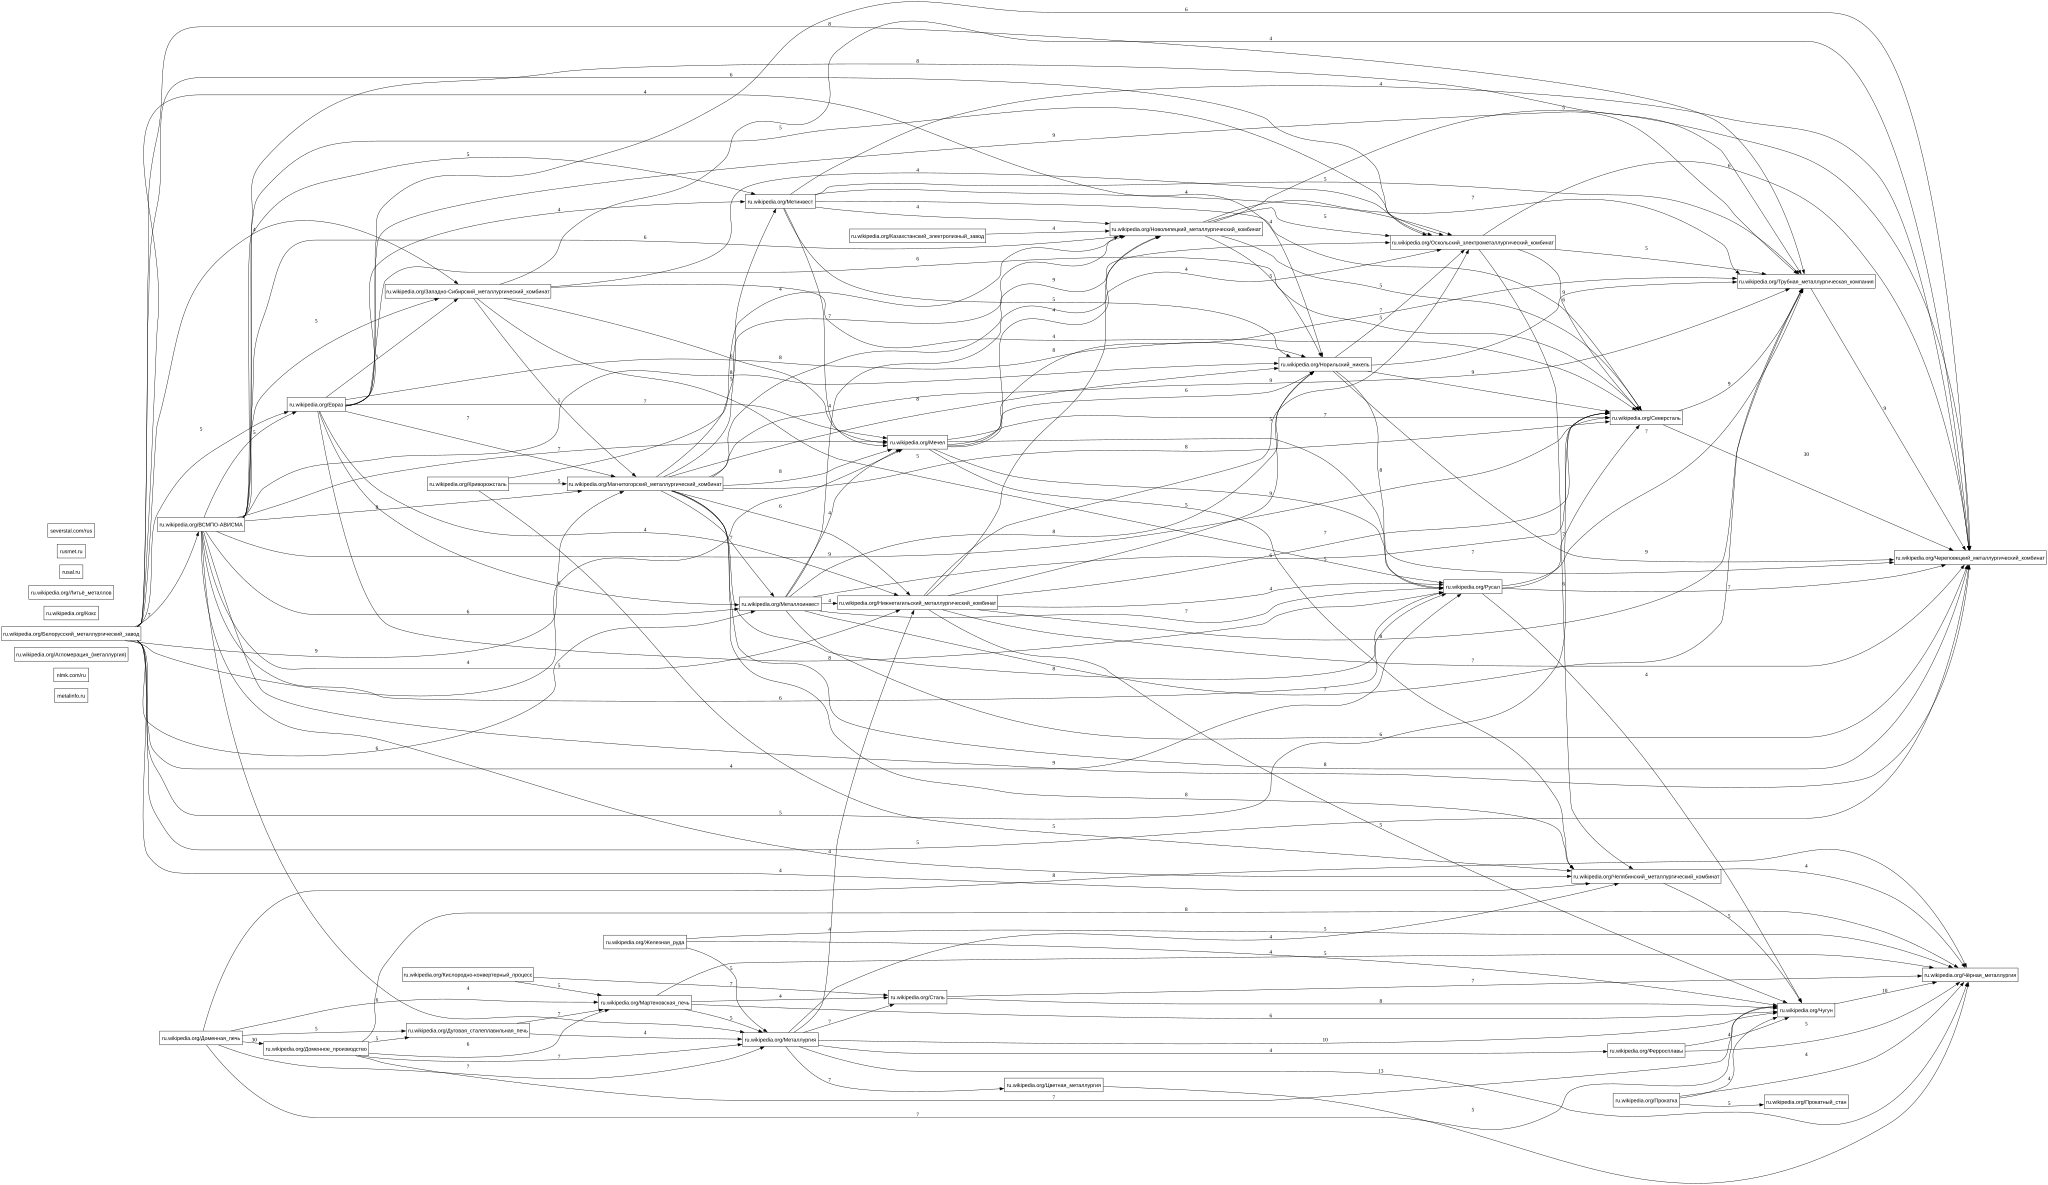

In [14]:
from IPython.display import SVG, display

picture = LAB / "task2/metallurgy_graph.dot.svg"
if picture.exists():
    display(SVG(filename=str(picture)))
else:
    print("Картинки нет — не установлена программа dot, см. README.")

---
# Выводы

**Задание 1.** Паук на Scrapy обходит пагинацию сам: `response.follow()` по ссылке «Next»
рекурсивно вызывает `parse`, обход останавливается, когда ссылки на странице больше нет.
Данные не нужно собирать в список — Scrapy складывает в выходной файл всё, что отдано
через `yield`.

**Задание 2.** Граф показывает, что ресурсы стягиваются в кластеры по общей терминологии:
статьи и предприятия чёрной металлургии (доменная печь, чугун, сталь, прокат) образуют
плотную группу, а цветная металлургия (алюминий, никель, глинозём) стоит отдельно —
общих терминов с чёрной металлургией у неё мало.

Порог `--min-common` определяет плотность графа: при малом значении получается клубок,
при большом граф рассыпается на изолированные узлы.

**Что мешало на практике:** часть корпоративных сайтов закрыта от роботов и отдаёт 403,
а Википедия ограничивает частоту анонимных обращений. Поэтому в списке ресурсов запас
по количеству, а приложение повторяет запросы с паузой и накапливает результат между
запусками.